# Notebook per Pre-training Self-Supervised (SpectraMAE / HybridMAE)

Questo notebook implementa il pre-training di un Masked Autoencoder per spettri Raman.
Supporta sia l'architettura **SpectraMAE** (solo Transformer) sia l'architettura **HybridMAE** (CNN + Transformer).
Il modello e tutti gli iperparametri vengono caricati da un file `.yaml`, garantendo riproducibilità e flessibilità.

**Struttura del Notebook:**
1. **Setup**: Librerie, seed globale, path di progetto.
2. **Configurazione**: Lettura del file `.yaml` (passato via env var `EXP_CONFIG_FILE` o default).
3. **Caricamento Dati**: Dataset di pre-training (solo spettri, senza etichette).
4. **Costruzione Modello**: Factory da config (`Spectra_MAE` o `HybridMAE`).
5. **Training Engine**: Loop MAE unificato che gestisce entrambe le architetture.
6. **Esecuzione**: Avvio training e salvataggio checkpoint.
7. **Visualizzazione**: Curve di loss e spettri originali vs ricostruiti.

In [1]:
# --- CELLA 1: SETUP AMBIENTE E IMPORTAZIONI ---
import sys
import os
import yaml
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# ========== GLOBAL SEED FOR REPRODUCIBILITY ==========
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'✅ Global seed set to {SEED} for reproducibility')
# =====================================================

PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)
print(f'Working dir: {os.getcwd()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Setup completato! Stiamo usando: {device}')

✅ Global seed set to 42 for reproducibility
Working dir: /media/beegfs/home/y222/y222446/SpectraBreast
✅ Setup completato! Stiamo usando: cuda


In [2]:
# --- CELLA 2: LETTURA CONFIGURAZIONE ---
import shutil

# Prende il config dalla shell, oppure usa il default HybridMAE se lanciato a mano
# Per Spectra_MAE: configs/pretraining/exp_01_smae_baseline.yaml
# Per HybridMAE:   configs/pretraining/exp_02_hybrid_mae_baseline.yaml
config_file = os.environ.get('EXP_CONFIG_FILE', 'configs/pretraining/exp_02_hybrid_mae_baseline.yaml')
assert os.path.exists(config_file), f'Config non trovato: {config_file}'

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)

# Rilevazione architettura
ARCHITECTURE = config.get('model', {}).get('architecture', 'Spectra_MAE')
print(f'🏗️  Architettura selezionata: {ARCHITECTURE}')

# Applica il seed specificato nel file di config, se presente
split_seed = config.get('split', {}).get('seed', None)
if split_seed is not None:
    SEED = int(split_seed)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
    print(f'✅ Seed da YAML attivo: {SEED}')

output_dir = config_file.replace('configs', 'experiments').replace('.yaml', '')
os.makedirs(output_dir, exist_ok=True)
shutil.copy(config_file, os.path.join(output_dir, 'config_usato.yaml'))

print(f"Esperimento in esecuzione: {config.get('experiment_name', 'unknown')}")
print(f'Config usato: {config_file}')
print(f'I risultati verranno salvati in:\n{output_dir}')

🏗️  Architettura selezionata: HybridMAE
✅ Seed da YAML attivo: 42
Esperimento in esecuzione: HybridMAE Pre-training Baseline
Config usato: configs/pretraining/exp_02_hybrid_mae_baseline.yaml
I risultati verranno salvati in:
experiments/pretraining/exp_02_hybrid_mae_baseline


In [3]:
# --- CELLA 3: CARICAMENTO DATI ---
import torch
import numpy as np
from src.data.mat_loader import load_mat_dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

ds_cfg = config.get('dataset', {})
dataset_path = ds_cfg.get('path')
print(f'Caricamento dati da: {dataset_path}...')

# Caricamento solo degli spettri X (pre-training non supervisionato)
loaded = load_mat_dataset(
    dataset_path,
    x_key=ds_cfg.get('x_key', 'X'),
    dataset_name=ds_cfg.get('name'),
)
X_data = loaded.X

# Controllo trasposizione (formato MATLAB: 500 x N -> va girata)
if X_data.shape[0] == 500 or (X_data.ndim == 2 and X_data.shape[1] > X_data.shape[0] and X_data.shape[0] < 1000):
    print(f"🔄 Rilevata matrice in formato MATLAB {X_data.shape}! Eseguo il transpose...")
    X_data = X_data.T

N, L = X_data.shape
print(f"✅ Dati pronti: {N} spettri di lunghezza {L}")

# Split dei dati (solo train e val per pre-training)
split_cfg = config.get('split', {}).get('holdout', {})
test_size = float(split_cfg.get('test_size', 0.2))
val_size_of_temp = float(split_cfg.get('val_size_of_temp', 0.25))

idx = np.arange(N)
idx_train, idx_temp = train_test_split(idx, test_size=test_size, random_state=SEED)
idx_val, idx_test = train_test_split(idx_temp, test_size=val_size_of_temp, random_state=SEED)

# Tensori shape (B, 1, L) per CNN compatibility
tensor_x_train = torch.tensor(X_data[idx_train], dtype=torch.float32).unsqueeze(1)
tensor_x_val   = torch.tensor(X_data[idx_val],   dtype=torch.float32).unsqueeze(1)

BATCH_SIZE = int(ds_cfg.get('batch_size', config.get('training', {}).get('batch_size', 128)))

train_loader = DataLoader(TensorDataset(tensor_x_train), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TensorDataset(tensor_x_val),   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

test_batch = next(iter(train_loader))[0]
print("-" * 50)
print(f"🚀 VERIFICA FINALE FORMA BATCH: {list(test_batch.shape)}")
print(f"   Train: {len(idx_train)} | Val: {len(idx_val)} | Test (non usato): {len(idx_test)}")
print("-" * 50)

Caricamento dati da: data/PreTrain/SUPER_PRETRAIN_500pt.mat...


🔄 Rilevata matrice in formato MATLAB (500, 503561)! Eseguo il transpose...
✅ Dati pronti: 503561 spettri di lunghezza 500


--------------------------------------------------
🚀 VERIFICA FINALE FORMA BATCH: [128, 1, 500]
   Train: 402848 | Val: 75534 | Test (non usato): 25179
--------------------------------------------------


In [4]:
# --- CELLA 4: COSTRUZIONE MODELLO ---
from src.models.factory import build_model_from_config

model = build_model_from_config(config, device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Modello '{ARCHITECTURE}' costruito con successo.")
print(f"   Numero di parametri trainable: {n_params:,}")
print(f"   Classe modello: {type(model).__name__}")

✅ Modello 'HybridMAE' costruito con successo.
   Numero di parametri trainable: 643,331
   Classe modello: HybridMAE


In [5]:
# --- CELLA 5: TRAINING ENGINE PER MASKED AUTOENCODER ---
# Supporta sia Spectra_MAE (forward -> loss, pred, mask)
#         sia HybridMAE    (forward -> pred, mask, loss calcolata qui)
import torch.optim as optim
from tqdm.auto import tqdm


def _compute_hybrid_mae_loss(pred, target, mask):
    """
    Loss MSE only on masked positions.
    pred, target: (B, 1, L)
    mask:         (B, L, 1)  -- 1=masked, 0=visible
    """
    mask_t = mask.transpose(1, 2)              # (B, 1, L)
    import torch.nn.functional as F
    mask_up = F.interpolate(mask_t.float(), size=target.shape[-1], mode='nearest')
    loss = ((pred - target) ** 2 * mask_up).sum() / (mask_up.sum() + 1e-8)
    return loss


def forward_and_loss(model, spectra, architecture):
    """
    Unified forward pass that returns (loss, pred, mask) for any architecture.
    """
    if architecture == 'HybridMAE':
        pred, mask = model(spectra)          # pred: (B,1,L), mask: (B,L,1)
        loss = _compute_hybrid_mae_loss(pred, spectra, mask)
        return loss, pred, mask
    else:
        # Spectra_MAE already returns (loss, pred, mask)
        return model(spectra)


def _check_spectra_shape(spectra):
    """Ensure shape is (B, 1, L)."""
    if spectra.dim() == 2:
        spectra = spectra.unsqueeze(1)
    elif spectra.dim() == 3 and spectra.shape[1] != 1:
        spectra = spectra.transpose(1, 2)
    assert spectra.shape[1] == 1, f"Shape canale errata: {spectra.shape}"
    return spectra


def train_mae_one_epoch(model, loader, optimizer, device, architecture):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training Epoch", leave=False):
        spectra = _check_spectra_shape(batch[0].to(device))
        optimizer.zero_grad()
        loss, _, _ = forward_and_loss(model, spectra, architecture)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_mae(model, loader, device, architecture):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            spectra = _check_spectra_shape(batch[0].to(device))
            loss, _, _ = forward_and_loss(model, spectra, architecture)
            total_loss += loss.item()
    return total_loss / len(loader)


def train_mae(model, train_loader, val_loader, config, device, architecture):
    train_cfg = config.get('training', {})
    lr       = float(train_cfg.get('learning_rate', 1e-3))
    wd       = float(train_cfg.get('weight_decay', 0.05))
    epochs   = int(train_cfg.get('epochs', 50))
    patience = int(train_cfg.get('patience', 10))

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    scheduler_cfg = train_cfg.get('scheduler', {})
    if scheduler_cfg.get('name') == 'CosineAnnealingLR':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=int(scheduler_cfg.get('T_max', epochs))
        )
    else:
        scheduler = None

    history = {'train_loss': [], 'val_loss': []}
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None

    for epoch in range(epochs):
        train_loss = train_mae_one_epoch(model, train_loader, optimizer, device, architecture)
        val_loss   = evaluate_mae(model, val_loader, device, architecture)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

        if val_loss < best_loss:
            best_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"✨ Nuovo best model con validation loss: {best_loss:.6f}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"🛑 Early stopping dopo {patience} epoche senza miglioramenti.")
            break

    return best_state, history


print(f"✅ Training engine pronto per '{ARCHITECTURE}'.")

✅ Training engine pronto per 'HybridMAE'.


In [6]:
# --- CELLA 6: ESECUZIONE ADDESTRAMENTO ---
import json

print("="*50)
print(f"=== FASE DI PRE-TRAINING: {ARCHITECTURE} ===")
print("="*50)

best_weights, history = train_mae(model, train_loader, val_loader, config, device, ARCHITECTURE)

# Salva il modello migliore
model_save_path = os.path.join(output_dir, "best_pretrained_model.pth")
torch.save(best_weights, model_save_path)
print(f"✅ Modello pre-addestrato salvato in: {model_save_path}")

# Salva la history
history_path = os.path.join(output_dir, "pretrain_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✅ History salvata in: {history_path}")

=== FASE DI PRE-TRAINING: HybridMAE ===


Training Epoch:   0%|          | 0/3147 [00:00<?, ?it/s]

Validation:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 1/50 -> Train Loss: 0.001893, Val Loss: 0.000170
✨ Nuovo best model con validation loss: 0.000170


Training Epoch:   0%|          | 0/3147 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 49/50 -> Train Loss: 0.000045, Val Loss: 0.000043


Training Epoch:   0%|          | 0/3147 [00:00<?, ?it/s]

Validation:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 50/50 -> Train Loss: 0.000045, Val Loss: 0.000043
✅ Modello pre-addestrato salvato in: experiments/pretraining/exp_02_hybrid_mae_baseline/best_pretrained_model.pth
✅ History salvata in: experiments/pretraining/exp_02_hybrid_mae_baseline/pretrain_history.json


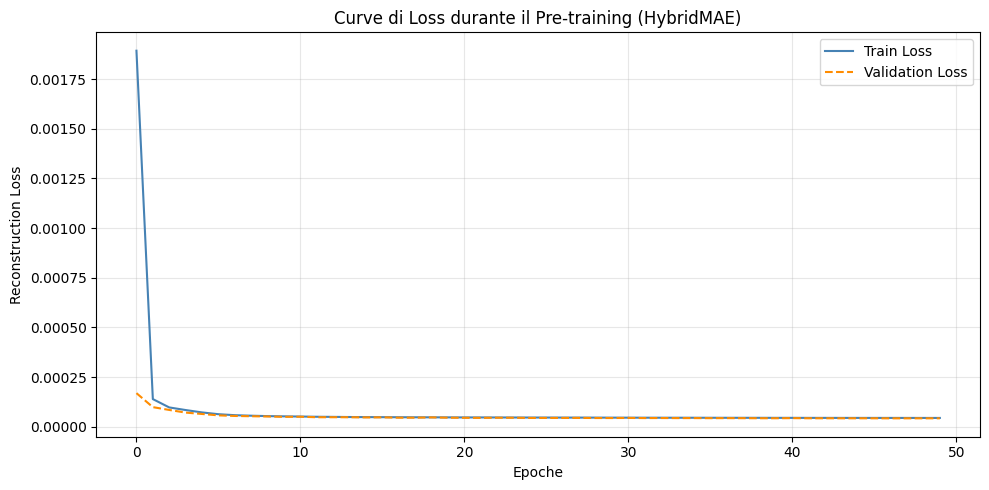


--- Visualizzazione Esempi di Ricostruzione ---


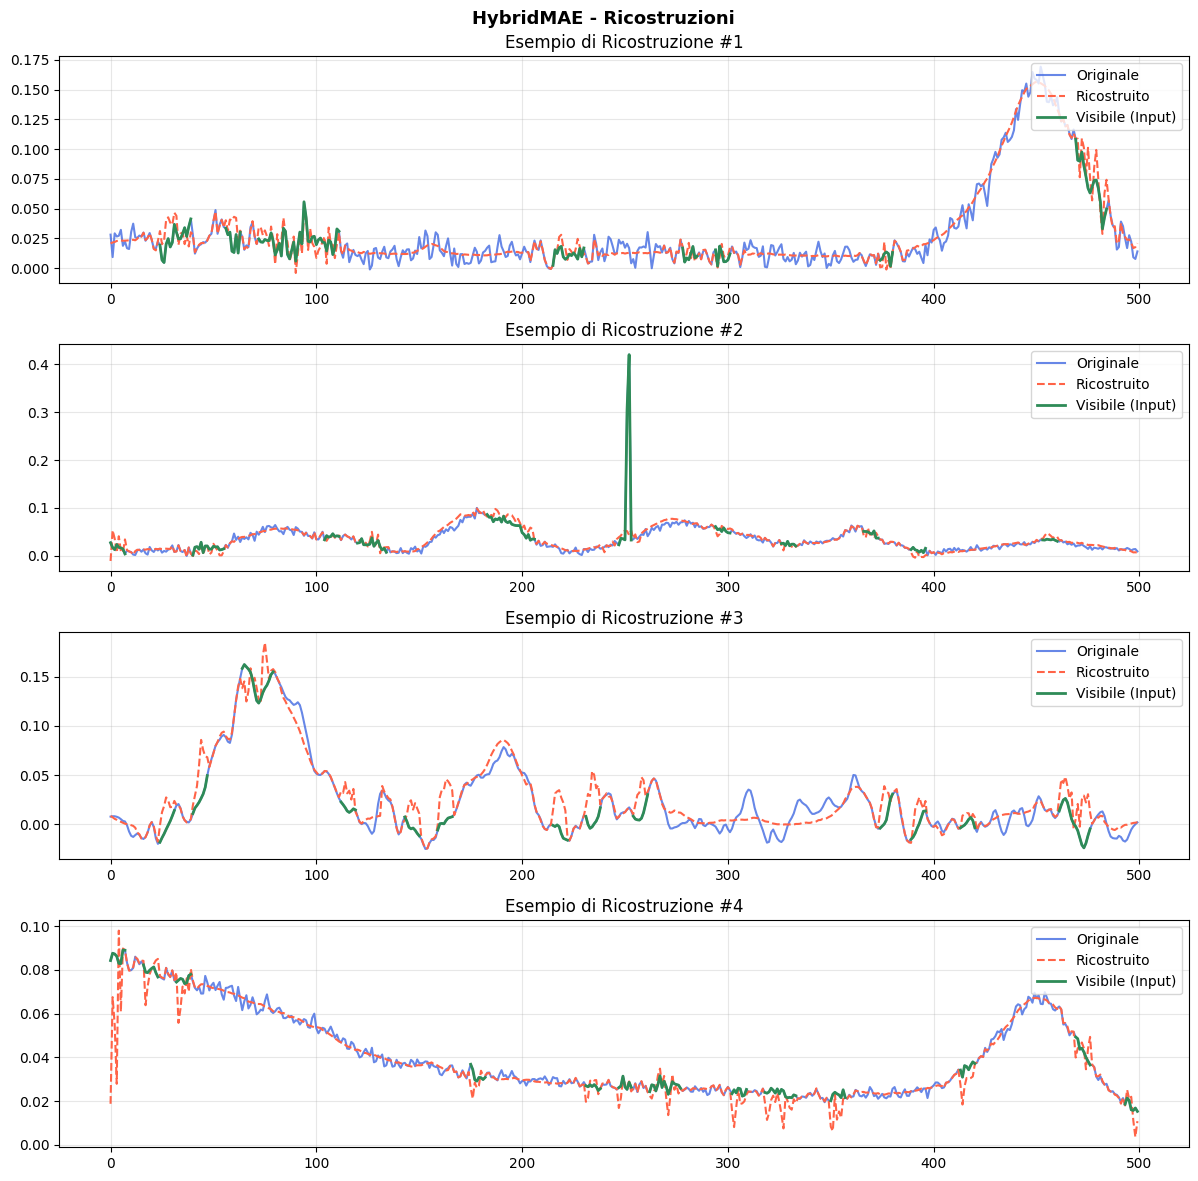

✅ Analisi qualitativa completata.
📂 Report salvato in: experiments/pretraining/exp_02_hybrid_mae_baseline/report


In [7]:
# --- CELLA 7: VISUALIZZAZIONE RISULTATI ---
report_dir = os.path.join(output_dir, "report")
os.makedirs(report_dir, exist_ok=True)

# ---- 7a: Curve di Loss ----
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss',      color='steelblue')
plt.plot(history['val_loss'],   label='Validation Loss', color='darkorange', linestyle='--')
plt.title(f'Curve di Loss durante il Pre-training ({ARCHITECTURE})')
plt.xlabel('Epoche')
plt.ylabel('Reconstruction Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(report_dir, "fig_pretrain_loss.png"), dpi=150)
plt.show()

# ---- 7b: Esempi di Ricostruzione ----
print("\n--- Visualizzazione Esempi di Ricostruzione ---")
model.load_state_dict(best_weights)
model.eval()

val_spectra_batch = next(iter(val_loader))[0].to(device)
val_spectra_batch = _check_spectra_shape(val_spectra_batch)

with torch.no_grad():
    _, pred, mask = forward_and_loss(model, val_spectra_batch, ARCHITECTURE)

# ---- Numpy conversion ----
original_np = val_spectra_batch.cpu().numpy()  # (B, 1, L)

if ARCHITECTURE == 'HybridMAE':
    # pred: (B, 1, L), mask: (B, L, 1) -> 1=masked
    reconstructed_np = pred.cpu().numpy()                      # (B, 1, L)
    import torch.nn.functional as F
    mask_t = mask.transpose(1, 2)
    mask_up = F.interpolate(mask_t.float(), size=val_spectra_batch.shape[-1], mode='nearest')
    mask_np = mask_up.cpu().numpy()               # (B, 1, L)
else:
    # Spectra_MAE: unpatchify both pred and mask
    reconstructed_np = model.unpatchify(pred).cpu().numpy()    # (B, 1, L)
    mask_det = mask.detach()
    mask_det = mask_det.unsqueeze(-1).repeat(1, 1, model.patch_size)
    mask_np = model.unpatchify(mask_det).cpu().numpy()         # (B, 1, L)

masked_spectra = original_np * (1 - mask_np)  # visible portion

# ---- Plot ----
n_examples = min(4, len(original_np))
fig, axes = plt.subplots(n_examples, 1, figsize=(12, 3 * n_examples))
if n_examples == 1:
    axes = [axes]

for i in range(n_examples):
    ax = axes[i]
    ax.plot(original_np[i].squeeze(),      label='Originale',        color='royalblue',  alpha=0.8)
    ax.plot(reconstructed_np[i].squeeze(), label='Ricostruito',      color='tomato',     linestyle='--')
    visible = np.ma.masked_where(mask_np[i].squeeze() == 1, original_np[i].squeeze())
    ax.plot(visible,                       label='Visibile (Input)', color='seagreen',   linewidth=2)
    ax.set_title(f'Esempio di Ricostruzione #{i+1}')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle(f'{ARCHITECTURE} - Ricostruzioni', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(report_dir, "fig_reconstruction_examples.png"), dpi=150)
plt.show()

print("✅ Analisi qualitativa completata.")
print(f"📂 Report salvato in: {report_dir}")